# NB4 · Revenue Impact Analysis

**Goal**: Translate churn into dollars.  
Business stakeholders respond to revenue numbers, not churn percentages.  
This notebook answers:
- How much Monthly Recurring Revenue (MRR) is lost to churn?
- Which segments drive the most revenue loss?
- What is a retained customer worth (simple LTV estimate)?
- What does a 5% / 10% churn reduction save in MRR?

**Requires**: `telco_segmented.csv` produced by NB3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('telco_segmented.csv')
churners = df[df['Churn_flag'] == 1].copy()
print(f'Total customers: {len(df):,}')
print(f'Churners: {len(churners):,}  ({len(churners)/len(df):.1%})')

Total customers: 7,043
Churners: 1,869  (26.5%)


## 1 · Total MRR lost to churn

Each churned customer's `MonthlyCharges` is MRR that is no longer coming in.  
We look at total lost MRR, average lost MRR per churner, and a waterfall by segment.

In [2]:
total_mrr = df['MonthlyCharges'].sum()
lost_mrr = churners['MonthlyCharges'].sum()
pct_lost = lost_mrr / total_mrr

print(f'Total MRR (all customers):   ${total_mrr:,.0f}')
print(f'MRR lost to churn:           ${lost_mrr:,.0f}  ({pct_lost:.1%} of total)')
print(f'Average lost per churner:    ${churners["MonthlyCharges"].mean():,.2f}/mo')
print(f'Projected annual revenue lost: ${lost_mrr * 12:,.0f}')

Total MRR (all customers):   $456,117
MRR lost to churn:           $139,131  (30.5% of total)
Average lost per churner:    $74.44/mo
Projected annual revenue lost: $1,669,570


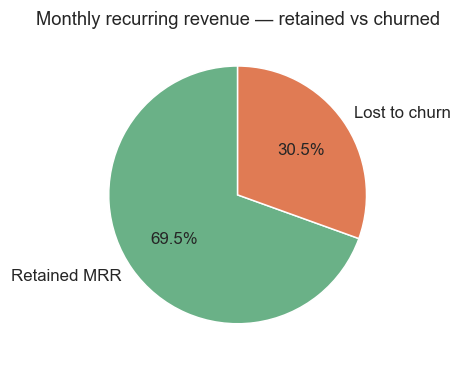

In [3]:
# MRR breakdown: retained vs lost
fig, ax = plt.subplots(figsize=(6, 3.5))
labels = ['Retained MRR', 'Lost to churn']
values = [total_mrr - lost_mrr, lost_mrr]
colors = ['#6ab187', '#e07b54']
wedges, texts, autotexts = ax.pie(values, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 11})
ax.set_title('Monthly recurring revenue — retained vs churned')
plt.tight_layout()
plt.show()

## 2 · Lost MRR by segment

Not all churn is equal. A churning power user costs far more than a churning new customer.  
We rank segments by total lost MRR — this tells us *where to focus retention spend*.

                    churners_n  lost_mrr  avg_monthly  pct_of_lost
segment                                                           
New & vulnerable          1024   68301.4         66.7         49.1
Established M2M            631   52545.6         83.3         37.8
Power user                 124   12895.6        104.0          9.3
Long-term contract          90    5388.1         59.9          3.9


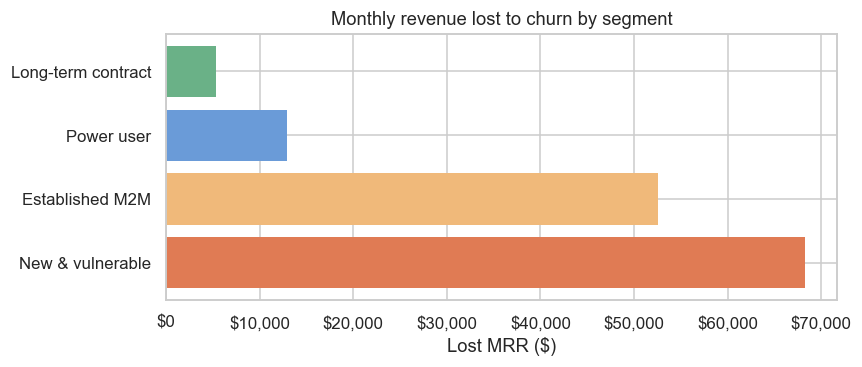

In [4]:
seg_mrr = churners.groupby('segment').agg(
    churners_n=('customerID', 'count'),
    lost_mrr=('MonthlyCharges', 'sum'),
    avg_monthly=('MonthlyCharges', 'mean')
).sort_values('lost_mrr', ascending=False)

seg_mrr['pct_of_lost'] = seg_mrr['lost_mrr'] / lost_mrr * 100
print(seg_mrr.round(1))

fig, ax = plt.subplots(figsize=(8, 3.5))
palette = {'New & vulnerable': '#e07b54', 'Established M2M': '#f0b97a',
           'Power user': '#6a9bd8', 'Long-term contract': '#6ab187'}
colors = [palette.get(s, 'gray') for s in seg_mrr.index]
ax.barh(seg_mrr.index, seg_mrr['lost_mrr'], color=colors, edgecolor='none')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Monthly revenue lost to churn by segment')
ax.set_xlabel('Lost MRR ($)')
plt.tight_layout()
plt.show()

## 3 · Simple LTV estimate

LTV = Monthly Charges × Expected tenure in months.  
We use average tenure of non-churners as the 'expected lifetime' for a retained customer.  
This gives us a ceiling for how much it's worth spending to retain one customer.

In [5]:
avg_tenure_retained = df[df['Churn_flag'] == 0]['tenure'].mean()
avg_monthly_retained = df[df['Churn_flag'] == 0]['MonthlyCharges'].mean()
avg_tenure_churner = churners['tenure'].mean()
avg_monthly_churner = churners['MonthlyCharges'].mean()

ltv_retained = avg_monthly_retained * avg_tenure_retained
ltv_churner  = avg_monthly_churner  * avg_tenure_churner

print(f'Avg tenure  — retained: {avg_tenure_retained:.1f} mo   churner: {avg_tenure_churner:.1f} mo')
print(f'Avg monthly — retained: ${avg_monthly_retained:.2f}    churner: ${avg_monthly_churner:.2f}')
print(f'')
print(f'Simple LTV — retained customer:  ${ltv_retained:,.0f}')
print(f'Simple LTV — churned customer:   ${ltv_churner:,.0f}')
print(f'Value gap per saved customer:    ${ltv_retained - ltv_churner:,.0f}')

Avg tenure  — retained: 37.6 mo   churner: 18.0 mo
Avg monthly — retained: $61.27    churner: $74.44

Simple LTV — retained customer:  $2,302
Simple LTV — churned customer:   $1,338
Value gap per saved customer:    $963


## 4 · Retention ROI simulator

How much MRR could we save with a 5%, 10%, or 20% reduction in churn?  
We also model the break-even cost per retained customer.

churn_reduction  customers_saved  monthly_mrr_saved  annual_saved
             5%               93           10137.45      121649.4
            10%              186           19813.05      237756.6
            15%              280           29258.35      351100.2
            20%              373           38370.75      460449.0


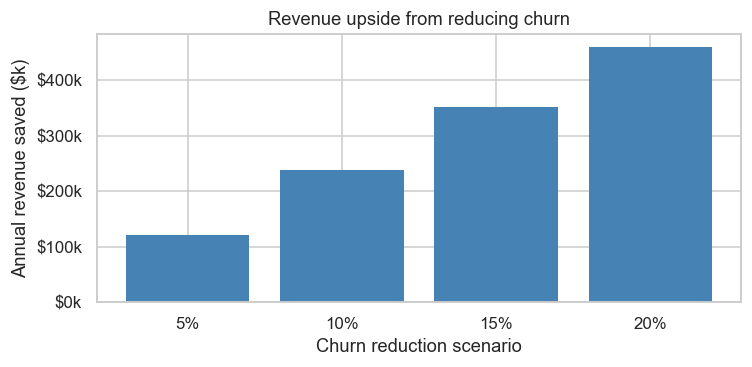

In [6]:
reduction_scenarios = [0.05, 0.10, 0.15, 0.20]
rows = []

for r in reduction_scenarios:
    saved_customers = int(len(churners) * r)
    saved_mrr = churners.nlargest(saved_customers, 'MonthlyCharges')['MonthlyCharges'].sum()
    rows.append({
        'churn_reduction': f'{r:.0%}',
        'customers_saved': saved_customers,
        'monthly_mrr_saved': saved_mrr,
        'annual_saved': saved_mrr * 12
    })

roi_df = pd.DataFrame(rows)
print(roi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(roi_df['churn_reduction'], roi_df['annual_saved'] / 1000,
       color='steelblue', edgecolor='none')
ax.set_xlabel('Churn reduction scenario')
ax.set_ylabel('Annual revenue saved ($k)')
ax.set_title('Revenue upside from reducing churn')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}k'))
plt.tight_layout()
plt.show()

## 5 · Monthly charge distribution — churners vs retained

This confirms whether high-value or low-value customers are churning more.  
Shapes the pricing and discount strategy in NB5.

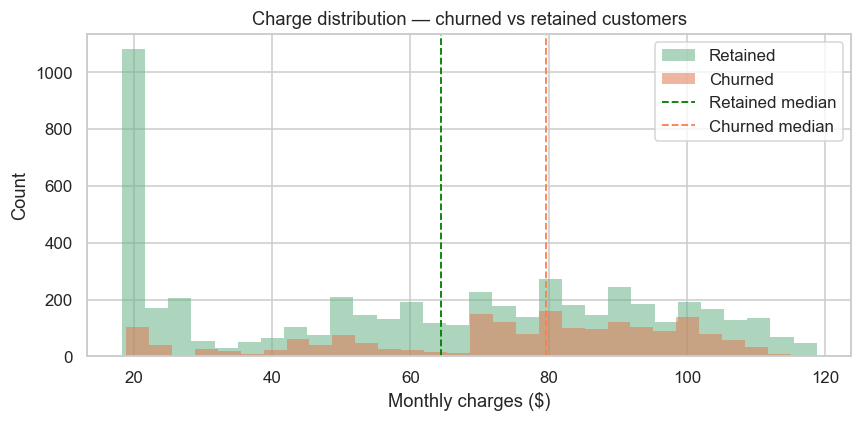

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Churn_flag'] == 0]['MonthlyCharges'].plot.hist(
    ax=ax, bins=30, alpha=0.55, label='Retained', color='#6ab187', edgecolor='none')
churners['MonthlyCharges'].plot.hist(
    ax=ax, bins=30, alpha=0.55, label='Churned', color='#e07b54', edgecolor='none')
ax.axvline(df[df['Churn_flag']==0]['MonthlyCharges'].median(), color='green',
           linestyle='--', linewidth=1.2, label='Retained median')
ax.axvline(churners['MonthlyCharges'].median(), color='coral',
           linestyle='--', linewidth=1.2, label='Churned median')
ax.set_xlabel('Monthly charges ($)')
ax.set_ylabel('Count')
ax.set_title('Charge distribution — churned vs retained customers')
ax.legend()
plt.tight_layout()
plt.show()